# fgrad demo

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from fgrad.value import Value
from fgrad.nn import Neuron, Layer, MLP

In [5]:
np.random.seed(42)
random.seed(42)

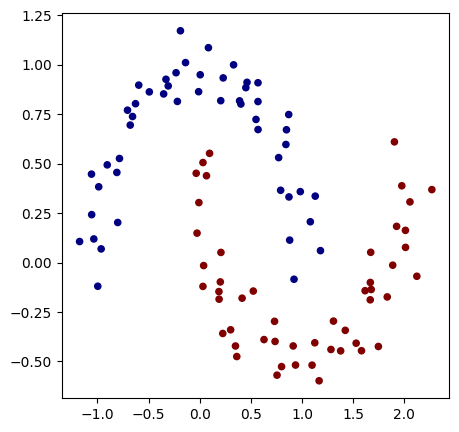

In [6]:
from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)

y = y*2 - 1 # regularization

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=20, cmap='jet')

In [7]:
model = MLP.uniform(2, [16, 16, 1])
print(model)
print(f"number of parameters: {len(model.parameters())}")

MLP(layers=[Layer(neurons=[Neuron(w=[Value(0.2788535969157675), Value(-0.9499784895546661)], b=Value(0.0), nonlin=True), Neuron(w=[Value(-0.4499413632617615), Value(-0.5535785237023545)], b=Value(0.0), nonlin=True), Neuron(w=[Value(0.4729424283280248), Value(0.3533989748458226)], b=Value(0.0), nonlin=True), Neuron(w=[Value(0.7843591354096908), Value(-0.8261223347411677)], b=Value(0.0), nonlin=True), Neuron(w=[Value(-0.15615636062945915), Value(-0.9404055611238593)], b=Value(0.0), nonlin=True), Neuron(w=[Value(-0.5627240503927933), Value(0.010710576206724776)], b=Value(0.0), nonlin=True), Neuron(w=[Value(-0.9469280606322728), Value(-0.602324698626703)], b=Value(0.0), nonlin=True), Neuron(w=[Value(0.2997688755590464), Value(0.08988296120643335)], b=Value(0.0), nonlin=True), Neuron(w=[Value(-0.5591187559186066), Value(0.17853136775181744)], b=Value(0.0), nonlin=True), Neuron(w=[Value(0.6188609133556533), Value(-0.987002480643878)], b=Value(0.0), nonlin=True), Neuron(w=[Value(0.61163850366

In [8]:
def loss(batch_size=None):

    if batch_size is None:
        Xb, yb = X, y
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]
    inputs = [list(map(Value.from_data, xrow)) for xrow in Xb]

    scores = list(map(model, inputs))

    losses = [(1 + -yi*scorei[0]).relu() for yi, scorei in zip(yb, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))

    reg_loss = sum((p*p for p in model.parameters()))
    total_loss = data_loss + 1e-4 * reg_loss

    accuracy = [(yi > 0) == (scorei[0].data > 0) for yi, scorei in zip(yb, scores)]
    return total_loss, sum(accuracy) / len(accuracy)

total_loss, accuracy = loss()
print(total_loss, accuracy)

Value(0.7157075494482541) 0.72


In [9]:
from fgrad.value import backward

for k in range(100):
    total_loss, acc = loss()
    grads = backward(total_loss)
    lr = 1.0 - 0.9 * k / 100
    for p in model.parameters():
        p.data -= lr * grads[p]
    if k % 1 == 0:
        print(f"step {k} loss {total_loss.data}, accuracy {acc*100}%")

step 0 loss 0.7157075494482541, accuracy 72.0%
step 1 loss 1.644142932285452, accuracy 50.0%
step 2 loss 1.4234991381329356, accuracy 60.0%
step 3 loss 0.5172470301127354, accuracy 81.0%
step 4 loss 0.7647260674692989, accuracy 81.0%
step 5 loss 0.38914291888813796, accuracy 84.0%
step 6 loss 0.30180851162239974, accuracy 86.0%
step 7 loss 0.2494684092118604, accuracy 89.0%
step 8 loss 0.24986625729873155, accuracy 90.0%
step 9 loss 0.2681148927035831, accuracy 90.0%
step 10 loss 0.3188973561844591, accuracy 89.0%
step 11 loss 0.23633097400101405, accuracy 91.0%
step 12 loss 0.26660523111276424, accuracy 90.0%
step 13 loss 0.1530015069614059, accuracy 93.0%
step 14 loss 0.12256852436374639, accuracy 96.0%
step 15 loss 0.1334787626652808, accuracy 94.0%
step 16 loss 0.1238547040027832, accuracy 97.0%
step 17 loss 0.15423206113281362, accuracy 94.0%
step 18 loss 0.22694842493957945, accuracy 95.0%
step 19 loss 0.18216225667622635, accuracy 94.0%
step 20 loss 0.11194357623907447, accuracy

(-1.5978882018302847, 2.1521117981697153)

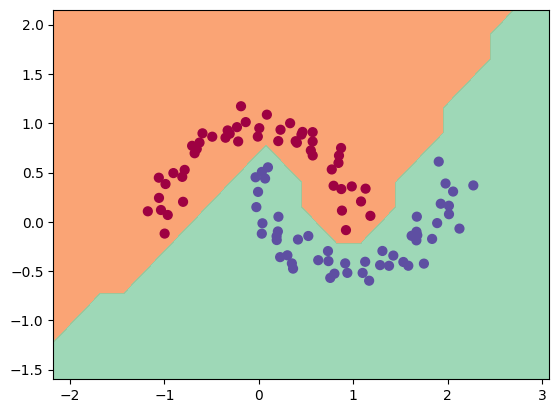

In [12]:
h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value.from_data, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s[0].data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())